In [ ]:
import zipfile

with zipfile.ZipFile("traffic.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os

os.listdir("dataset")

['smart-city-traffic-patterns']

In [ ]:
os.listdir("dataset/smart-city-traffic-patterns")

['datasets_8494_11879_test_BdBKkAj.csv', 'train_aWnotuB.csv']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
data = pd.read_csv("dataset/smart-city-traffic-patterns/train_aWnotuB.csv")
data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
print(data.columns)

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')


In [ ]:
data['DateTime'] = pd.to_datetime(data['DateTime'])

data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
data['Year'] = data['DateTime'].dt.year
data['Month'] = data['DateTime'].dt.month
data['Day'] = data['DateTime'].dt.day
data['Hour'] = data['DateTime'].dt.hour

data.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4


In [ ]:
X = data[['Junction', 'Year', 'Month', 'Day', 'Hour']]
y = data['Vehicles']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

[26.51767083 14.8895708  17.67889456 23.26202561 32.86814251 13.04762153
 14.42763618 22.38428718 23.42010262 -0.0669374 ]


In [ ]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 9.75185228646918


In [ ]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 9.75185228646918


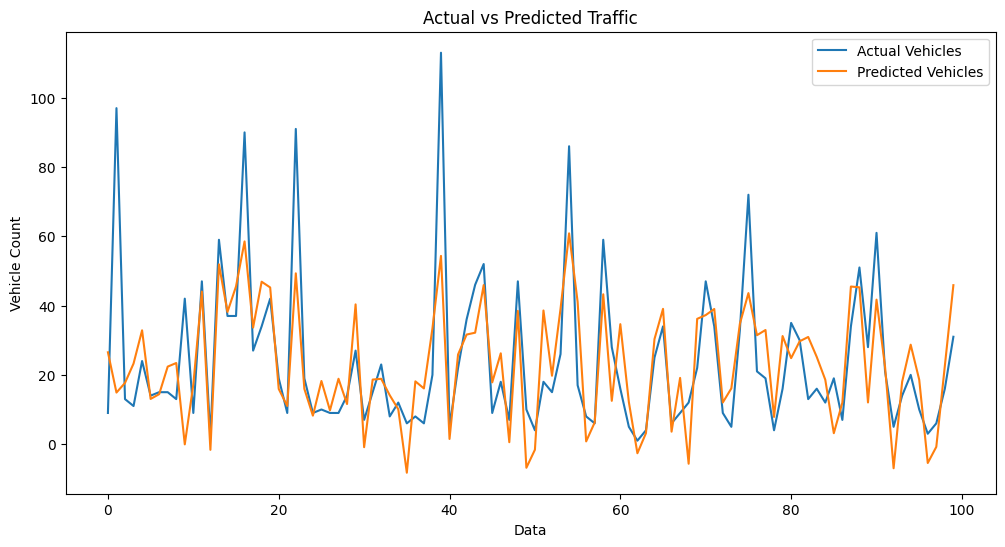

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Vehicles')
plt.plot(predictions[:100], label='Predicted Vehicles')

plt.xlabel("Data")
plt.ylabel("Vehicle Count")
plt.title("Actual vs Predicted Traffic")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("R2 Score:", score)

R2 Score: 0.5834783350948503


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:10])

[ 9.6  57.07  8.49 10.6  19.04 10.89 12.6  15.35 12.51 18.6 ]


In [ ]:
rf_error = mean_absolute_error(y_test, rf_predictions)

rf_score = r2_score(y_test, rf_predictions)

print("Random Forest Error:", rf_error)

print("Random Forest R2 Score:", rf_score)

Random Forest Error: 2.8698742726517037
Random Forest R2 Score: 0.9545210892018186


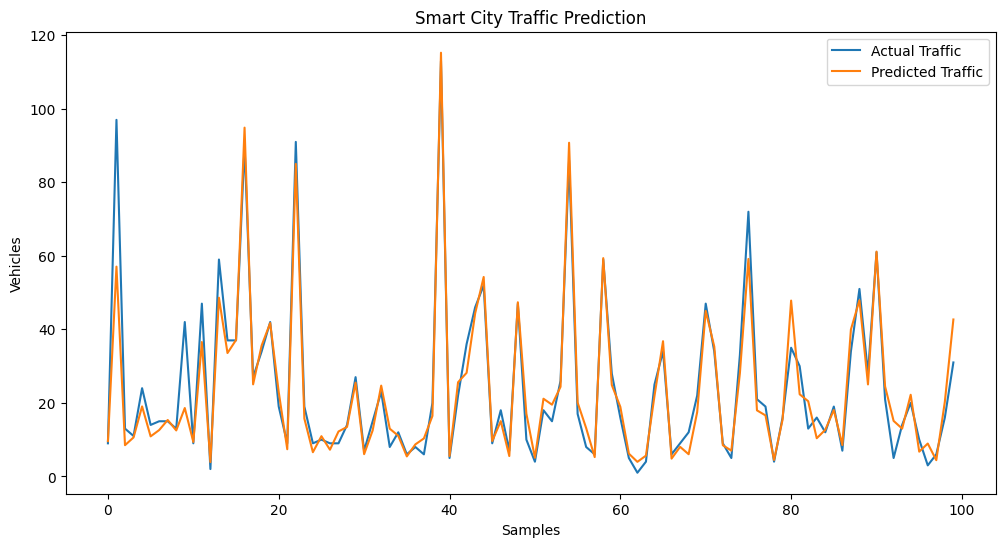

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Traffic')
plt.plot(rf_predictions[:100], label='Predicted Traffic')

plt.title("Smart City Traffic Prediction")

plt.xlabel("Samples")
plt.ylabel("Vehicles")

plt.legend()

plt.show()